In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.7 MB/s eta 0:00:00


In [2]:
import os
base = '/kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo'
for split in ['train', 'val']:
    imgs = os.listdir(f'{base}/images/{split}')
    lbls = os.listdir(f'{base}/labels/{split}')
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels")

train: 168 images, 168 labels
val: 42 images, 42 labels


In [3]:
label_dir = f'{base}/labels/train'
sample = os.listdir(label_dir)[0]
with open(f'{label_dir}/{sample}') as f:
    print(f.read()[:300])

1 0.7125 0.6611111111111111 0.7125 0.6638888888888889 0.7203125 0.6777777777777778 0.721875 0.6777777777777778 0.734375 0.7 0.7359375 0.7 0.74375 0.7138888888888889 0.7453125 0.7138888888888889 0.746875 0.7166666666666667 0.746875 0.7194444444444444 0.7484375 0.7194444444444444 0.75 0.72222222222222


In [4]:
import shutil, yaml

src_yaml = f'{base}/data.yaml'
dst_yaml = '/kaggle/working/data.yaml'
shutil.copy(src_yaml, dst_yaml)

with open(dst_yaml) as f:
    cfg = yaml.safe_load(f)

cfg['path'] = base  
cfg['train'] = 'images/train'
cfg['val'] = 'images/val'

with open(dst_yaml, 'w') as f:
    yaml.dump(cfg, f)

print(cfg)

{'train': 'images/train', 'val': 'images/val', 'nc': 2, 'names': ['dashed_line', 'solid_line'], 'path': '/kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo'}


In [5]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')  

results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    
    flipud=0.0,       
    fliplr=0.0,       
    degrees=5,        
    mosaic=1.0,
    scale=0.4,
    hsv_h=0.01,      
    hsv_s=0.3,
    hsv_v=0.4,      
    
    # Output
    project='/kaggle/working/lane_seg',
    name='v1',
    save=True,
    plots=True,       
    patience=30,      
    lr0=0.01,
    weight_decay=0.0005,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=6

In [6]:
model_best = YOLO('/kaggle/working/lane_seg/v1/weights/best.pt')
metrics = model_best.val(data='/kaggle/working/data.yaml')
print(f"mAP50: {metrics.seg.map50:.3f}")
print(f"mAP50-95: {metrics.seg.map:.3f}")

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 98.4±16.3 MB/s, size: 88.8 KB)
val: Scanning /kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo/labels/val... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 447.0it/s 0.1s
val: /kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo/images/val/video8_frame_00000.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.2s1.3s
                   all         42        639      0.906      0.847      0.894      0.699      0.782      0.712      0.721      0.384
    


image 1/1 /kaggle/input/datasets/snvngc11/lane-line-detection/dataset_yolo/images/val/video6_frame_02533.jpg: 384x640 19 dashed_lines, 5 solid_lines, 56.5ms
Speed: 1.2ms preprocess, 56.5ms inference, 13.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/test_pred/run1


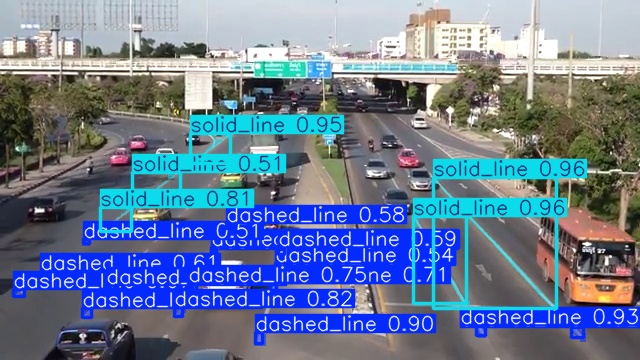

In [7]:
import cv2
from pathlib import Path

val_imgs = list(Path(f'{base}/images/val').glob('*.jpg'))
test_img = str(val_imgs[0])

result = model_best.predict(test_img, conf=0.25, save=True, 
                            project='/kaggle/working/test_pred', name='run1')

# Visualize
from IPython.display import Image
pred_path = '/kaggle/working/test_pred/run1/' + Path(test_img).name
Image(pred_path)

In [8]:
import shutil
shutil.copy('/kaggle/working/lane_seg/v1/weights/best.pt', 
            '/kaggle/working/best_lane_seg.pt')
print("Done — download best_lane_seg.pt")

Done — download best_lane_seg.pt
